In [1]:
!pip -q install sacrebleu bert-score nltk pandas numpy matplotlib sentencepiece torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.7 MB/s eta 0:00:00


## 2. Expected files
Place the dataset files in the working directory:
- `train_sa.csv`, `dev_sa.csv`, `test_sa.csv`
- `train_en.csv`, `dev_en.csv`, `test_en.csv`

In [ ]:
import os, re, time, math, random
from dataclasses import dataclass
from typing import List, Tuple
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from nltk.translate.bleu_score import corpus_bleu
from bert_score import score as bertscore_score
import matplotlib.pyplot as plt

SEED = 42
DATA_DIR = Path('./dataset')
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
SPECIAL_TOKENS = {'<pad>':0, '<bos>':1, '<eos>':2, '<unk>':3}
PAD_IDX, BOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3

def normalize_text(x: str) -> str:
    x = str(x).strip()
    x = re.sub(r'\s+', ' ', x)
    return x

def tokenize_sa(x: str):
    return normalize_text(x).split(' ')

def tokenize_en(x: str):
    x = normalize_text(x.lower())
    x = re.sub(r"([^a-z0-9' -])", r' \1 ', x)
    x = re.sub(r'\s+', ' ', x).strip()
    return x.split(' ') if x else []

class Vocab:
    def __init__(self, min_freq=1):
        self.min_freq = min_freq
        self.stoi = dict(SPECIAL_TOKENS)
        self.itos = {i:s for s,i in self.stoi.items()}

    def build(self, token_lists):
        from collections import Counter
        c = Counter()
        for toks in token_lists:
            c.update(toks)
        idx = len(self.stoi)
        for tok, freq in c.items():
            if freq >= self.min_freq and tok not in self.stoi:
                self.stoi[tok] = idx
                self.itos[idx] = tok
                idx += 1

    def encode(self, toks):
        return [self.stoi.get(t, UNK_IDX) for t in toks]

    def decode(self, ids, stop_at_eos=True):
        out = []
        for i in ids:
            tok = self.itos.get(int(i), '<unk>')
            if stop_at_eos and tok == '<eos>':
                break
            if tok not in ['<bos>', '<pad>']:
                out.append(tok)
        return out

    def __len__(self):
        return len(self.stoi)

In [ ]:
def read_parallel(src_file, tgt_file=None, src_col=None, tgt_col=None):
    src_df = pd.read_csv(DATA_DIR / src_file)
    src_col = src_col or [c for c in src_df.columns if 'Sentence' in c][0]
    id_col = [c for c in src_df.columns if 'Source' in c][0]
    if tgt_file is None:
        return src_df[[id_col, src_col]].rename(columns={id_col:'Source_id', src_col:'src'})
    tgt_df = pd.read_csv(DATA_DIR / tgt_file)
    tgt_col = tgt_col or [c for c in tgt_df.columns if 'Sentence' in c][0]
    merged = src_df.merge(tgt_df, on=id_col)
    return merged[[id_col, src_col, tgt_col]].rename(columns={id_col:'Source_id', src_col:'src', tgt_col:'tgt'})

train_df = read_parallel('train_sa_10000.csv', 'train_en_10000.csv')
dev_df = read_parallel('dev_sa_1000.csv', 'dev_en_1000.csv')
test_df = read_parallel('test_sa_1000.csv')

for col in ['src']:
    train_df[col] = train_df[col].astype(str).map(normalize_text)
    dev_df[col] = dev_df[col].astype(str).map(normalize_text)
    test_df[col] = test_df[col].astype(str).map(normalize_text)
train_df['tgt'] = train_df['tgt'].astype(str).map(normalize_text)
dev_df['tgt'] = dev_df['tgt'].astype(str).map(normalize_text)

train_df.head(), dev_df.head(), test_df.head()

(   Source_id                                                src  \
 0          1                         "Ctrl, S नुत्वा रक्षन्तु।"   
 1          2                     गुरुः छात्रान् एकवारं पाठयति ।   
 2          3  चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...   
 3          4        वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।   
 4          5  "अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...   
 
                                                  tgt  
 0                              Save it with Ctrl, S.  
 1         Teacher will teach the students only once.  
 2  To recreate this animation, I have to take two...  
 3    I will choose Colors options by clicking on it.  
 4  "See the example here - one mountain, four vil...  ,
    Source_id                                                src  \
 0          1                                         ते वीराः ।   
 1          2  'इन्फ़ैनेट् लूप्' इतीदं व्यवस्थां निरुत्तरां क...   
 2          3  ततस्तस्य गात्रे निष्ठीवं दत्वा तेन

In [5]:
train_src_tok = train_df['src'].map(tokenize_sa).tolist()
train_tgt_tok = train_df['tgt'].map(tokenize_en).tolist()
dev_src_tok = dev_df['src'].map(tokenize_sa).tolist()
dev_tgt_tok = dev_df['tgt'].map(tokenize_en).tolist()

src_vocab = Vocab(min_freq=1)
tgt_vocab = Vocab(min_freq=1)
src_vocab.build(train_src_tok)
tgt_vocab.build(train_tgt_tok)
len(src_vocab), len(tgt_vocab)

(33278, 10743)

In [6]:
class NMTDataset(Dataset):
    def __init__(self, df, src_vocab, tgt_vocab=None):
        self.ids = df['Source_id'].tolist()
        self.src = [src_vocab.encode(tokenize_sa(x)) + [EOS_IDX] for x in df['src'].tolist()]
        self.has_tgt = tgt_vocab is not None and 'tgt' in df.columns
        if self.has_tgt:
            self.tgt = [[BOS_IDX] + tgt_vocab.encode(tokenize_en(x)) + [EOS_IDX] for x in df['tgt'].tolist()]

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        if self.has_tgt:
            return self.ids[idx], self.src[idx], self.tgt[idx]
        return self.ids[idx], self.src[idx]

def pad_batch(seqs, pad_value=PAD_IDX):
    max_len = max(len(x) for x in seqs)
    out = torch.full((len(seqs), max_len), pad_value, dtype=torch.long)
    for i, s in enumerate(seqs):
        out[i, :len(s)] = torch.tensor(s, dtype=torch.long)
    return out

def collate_train(batch):
    ids, src, tgt = zip(*batch)
    return list(ids), pad_batch(src), pad_batch(tgt)

def collate_test(batch):
    ids, src = zip(*batch)
    return list(ids), pad_batch(src)

train_ds = NMTDataset(train_df, src_vocab, tgt_vocab)
dev_ds = NMTDataset(dev_df, src_vocab, tgt_vocab)
test_ds = NMTDataset(test_df, src_vocab, None)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collate_train)
dev_loader = DataLoader(dev_ds, batch_size=64, shuffle=False, collate_fn=collate_train)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, collate_fn=collate_test)

In [7]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, num_layers=1, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.GRU(emb_dim, hid_dim, num_layers=num_layers, bidirectional=True, batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hid_dim * 2, hid_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        emb = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(emb)
        hidden = torch.tanh(self.fc(torch.cat((hidden[-2], hidden[-1]), dim=1)))
        return outputs, hidden

class AdditiveAttention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.attn = nn.Linear(hid_dim * 3, hid_dim)
        self.v = nn.Linear(hid_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs, mask):
        src_len = encoder_outputs.shape[1]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        scores = self.v(energy).squeeze(2)
        scores = scores.masked_fill(mask == 0, -1e9)
        return torch.softmax(scores, dim=1)

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, dropout=0.2):
        super().__init__()
        self.output_dim = output_dim
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_IDX)
        self.attention = AdditiveAttention(hid_dim)
        self.rnn = nn.GRU((hid_dim * 2) + emb_dim, hid_dim, batch_first=True)
        self.fc_out = nn.Linear((hid_dim * 2) + hid_dim + emb_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_tok, hidden, encoder_outputs, mask):
        input_tok = input_tok.unsqueeze(1)
        emb = self.dropout(self.embedding(input_tok))
        attn = self.attention(hidden, encoder_outputs, mask).unsqueeze(1)
        context = torch.bmm(attn, encoder_outputs)
        rnn_input = torch.cat((emb, context), dim=2)
        output, hidden_new = self.rnn(rnn_input, hidden.unsqueeze(0))
        output = output.squeeze(1)
        context = context.squeeze(1)
        emb = emb.squeeze(1)
        pred = self.fc_out(torch.cat((output, context, emb), dim=1))
        return pred, hidden_new.squeeze(0), attn.squeeze(1)

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def create_mask(self, src):
        return (src != PAD_IDX)

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.output_dim
        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size, device=src.device)
        encoder_outputs, hidden = self.encoder(src)
        input_tok = tgt[:, 0]
        mask = self.create_mask(src)
        for t in range(1, tgt_len):
            output, hidden, _ = self.decoder(input_tok, hidden, encoder_outputs, mask)
            outputs[:, t] = output
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input_tok = tgt[:, t] if teacher_force else top1
        return outputs

    @torch.no_grad()
    def greedy_decode(self, src, max_len=60):
        encoder_outputs, hidden = self.encoder(src)
        mask = self.create_mask(src)
        batch_size = src.size(0)
        input_tok = torch.full((batch_size,), BOS_IDX, dtype=torch.long, device=src.device)
        preds = [[] for _ in range(batch_size)]
        finished = [False] * batch_size
        for _ in range(max_len):
            output, hidden, _ = self.decoder(input_tok, hidden, encoder_outputs, mask)
            input_tok = output.argmax(1)
            for i, tok in enumerate(input_tok.tolist()):
                if not finished[i]:
                    preds[i].append(tok)
                    if tok == EOS_IDX:
                        finished[i] = True
            if all(finished):
                break
        return preds

In [8]:
EMB_DIM = 256
HID_DIM = 512
DROPOUT = 0.25
LR = 1e-3
EPOCHS = 20
CLIP = 1.0

enc = Encoder(len(src_vocab), EMB_DIM, HID_DIM, dropout=DROPOUT)
dec = Decoder(len(tgt_vocab), EMB_DIM, HID_DIM, dropout=DROPOUT)
model = Seq2Seq(enc, dec).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=LR)
sum(p.numel() for p in model.parameters() if p.requires_grad)

36964855

In [9]:
def train_epoch(model, loader, optimizer, criterion, clip):
    model.train()
    total_loss = 0.0
    for _, src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        out = model(src, tgt, teacher_forcing_ratio=0.5)
        logits = out[:, 1:].reshape(-1, out.size(-1))
        gold = tgt[:, 1:].reshape(-1)
        loss = criterion(logits, gold)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def generate_texts(model, loader, tgt_vocab, max_len=60):
    model.eval()
    ids_all, preds_all = [], []
    for batch in loader:
        ids = batch[0]
        src = batch[1].to(device)
        pred_ids = model.greedy_decode(src, max_len=max_len)
        pred_txt = [' '.join(tgt_vocab.decode(p)) for p in pred_ids]
        ids_all.extend(ids)
        preds_all.extend(pred_txt)
    return ids_all, preds_all

@torch.no_grad()
def evaluate_dev(model, dev_loader, dev_df, tgt_vocab):
    ids, preds = generate_texts(model, [(ids, src) for ids, src, _ in dev_loader], tgt_vocab)
    pred_df = pd.DataFrame({'Source_id': ids, 'pred': preds}).sort_values('Source_id')
    gold_df = dev_df[['Source_id', 'tgt']].copy().sort_values('Source_id')
    merged = gold_df.merge(pred_df, on='Source_id')
    refs = [[tokenize_en(x)] for x in merged['tgt'].tolist()]
    hyps = [tokenize_en(x) for x in merged['pred'].tolist()]
    bleu = corpus_bleu(refs, hyps)
    P, R, F1 = bertscore_score(merged['pred'].tolist(), merged['tgt'].tolist(), lang='en', rescale_with_baseline=True, verbose=False)
    return bleu, float(F1.mean().item()), merged

best_bleu = -1
history = []
for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, CLIP)
    bleu, bert_f1, merged_dev = evaluate_dev(model, dev_loader, dev_df, tgt_vocab)
    history.append({'epoch': epoch, 'train_loss': train_loss, 'dev_bleu': bleu, 'dev_bertscore_f1': bert_f1})
    print(epoch, train_loss, bleu, bert_f1)
    if bleu > best_bleu:
        best_bleu = bleu
        torch.save({'model_state': model.state_dict(), 'src_stoi': src_vocab.stoi, 'tgt_stoi': tgt_vocab.stoi}, 'best_model.pt')

hist_df = pd.DataFrame(history)
hist_df

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

19 1.3191106585180683 0.07357469970949138 0.1032879576086998


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


20 1.229280471042463 0.07673130050760245 0.12017477303743362


,epoch,train_loss,dev_bleu,dev_bertscore_f1
0,1,6.008838,0.013338,-0.144901
1,2,5.101947,0.034567,-0.046451
2,3,4.456561,0.045332,0.018954
3,4,3.756107,0.051390,0.049403
4,5,3.270499,0.054159,0.011058
5,6,2.957462,0.057294,0.054163
6,7,2.728901,0.058923,0.060066
7,8,2.498532,0.064134,0.079039
8,9,2.305525,0.066399,0.077702
9,10,2.164697,0.070502,0.074498


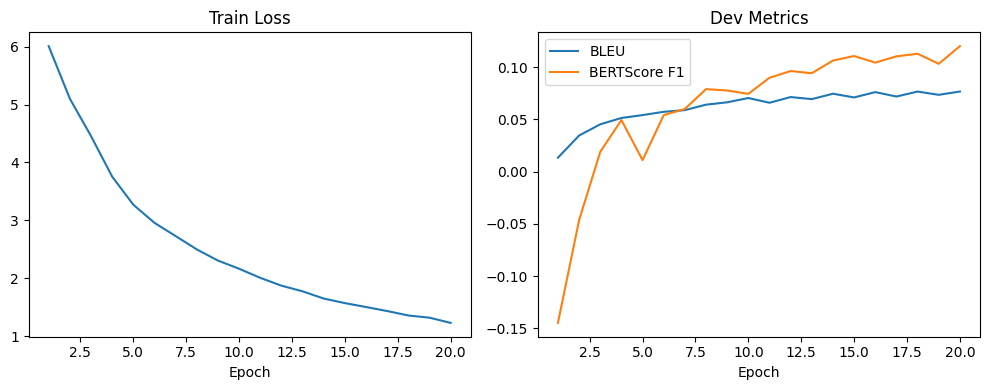

In [10]:
ckpt = torch.load('best_model.pt', map_location=device)
model.load_state_dict(ckpt['model_state'])

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(hist_df['epoch'], hist_df['train_loss'])
plt.title('Train Loss')
plt.xlabel('Epoch')
plt.subplot(1,2,2)
plt.plot(hist_df['epoch'], hist_df['dev_bleu'], label='BLEU')
plt.plot(hist_df['epoch'], hist_df['dev_bertscore_f1'], label='BERTScore F1')
plt.title('Dev Metrics')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.savefig('training_curves.png', dpi=200)
plt.show()

In [11]:
bleu, bert_f1, dev_preds = evaluate_dev(model, dev_loader, dev_df, tgt_vocab)
param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

start = time.time()
test_ids, test_preds = generate_texts(model, test_loader, tgt_vocab)
inference_time = time.time() - start

submission = pd.DataFrame({'Source_id': test_ids, 'Sentence_en': test_preds})
submission.to_csv('submission.csv', index=False, encoding='utf-8')

metrics_df = pd.DataFrame([{
    'dev_bleu': bleu,
    'dev_bertscore_f1': bert_f1,
    'test_inference_time_sec': inference_time,
    'trainable_parameters': param_count
}])
metrics_df.to_csv('metrics_summary.csv', index=False)

display(metrics_df)
display(submission.head())

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,dev_bleu,dev_bertscore_f1,test_inference_time_sec,trainable_parameters
0,0.076731,0.120175,1.467446,36964855


,Source_id,Sentence_en
0,1,range allows us to print the range of pages and
1,2,""" for many many i say unto them that were many..."
2,3,click on now i i go to the same button .
3,4,the first menu is be defined by default . we w...
4,5,and the chief captain that thou heard out of t...


In [12]:
sample_examples = dev_preds[['Source_id', 'tgt', 'pred']].copy()
sample_examples['src'] = dev_df.sort_values('Source_id')['src'].tolist()
sample_examples = sample_examples[['Source_id', 'src', 'tgt', 'pred']].head(10)
sample_examples.to_csv('translation_examples.csv', index=False)
sample_examples

,Source_id,src,tgt,pred
0,1,ते वीराः ।,Those are brave men.,those are two .
1,2,'इन्फ़ैनेट् लूप्' इतीदं व्यवस्थां निरुत्तरां क...,Infinite loop can cause the system to become u...,but us us go through the application .
2,3,ततस्तस्य गात्रे निष्ठीवं दत्वा तेन वेत्रेण शिर...,"""And they spit upon him, and took the reed, an...",""" every open them by them to be brought to them ."
3,4,एते तिथी ।,These two are dates.,these are are .
4,5,"""बहुविचारेषु जातषु पितर उत्थाय कथितवान्, हे भ्...","""And when there had been much disputing, Peter...",""" but those that them before unto him , thou h..."
5,6,यूयं भक्तियोगं पठथ।,You all are studying bhakti yoga.,you all are going .
6,7,voidइति मेथड् नाम टङ्कयतु ।,"So, type: void name of the method",name the method name .
7,8,"पाठेऽस्मिन् वयम्, awk इत्यस्मिन् if, else, els...","In this tutorial, we will learn about- if, els...","in this tutorial , we will learn about : varia..."
8,9,नूनम् ईषत् ‘S’ इति वक्रं तस्य उपरि स्थापयतु । ...,Just put a slight ‘S’ curve on it and I think ...,and on the image and on the layer mask and i t...
9,10,पुन: स्वस्थितौ आगच्छेत ।,• Come back to Sthiti.,let us milk . .
